# Why Your Electric Bill Stopped Following Fuel Prices
### A data investigation: US electricity prices, natural gas, inflation, and the new demand era (1978–2026)

**Ian Lee** | June 2026

**Question:** US electricity prices were flat for six years (2014–2020), then rose 46%. Is this just fuel costs and inflation — or is something new driving it?

**Approach:**
1. Pull 47 years of electricity price data (BLS via FRED)
2. Benchmark against overall inflation (CPI)
3. Test the traditional driver: natural gas prices, with lag analysis
4. Build a two-factor model (gas + CPI) and examine what it *can't* explain

**Headline findings:**
- Electricity prices ratchet: they follow natural gas up, but don't follow it back down. Gas gave back its entire 2022 spike; electricity gave back nothing.
- Retail electricity responds to wholesale gas with a ~6-month lag (r = 0.53).
- After accounting for both fuel costs and general inflation, electricity inflation has run roughly +3 points/year hotter than the model predicts — persistently — since 2023, coinciding with the first sustained US power demand growth in two decades (datacenter buildout).

**Honest caveats:** the unexplained residual is "not gas, not CPI" — it bundles datacenter demand with grid capex, plant retirements, and electrification. Similar residual episodes existed before (2005–09, driven by rate-cap expirations) but decayed; this one hasn't yet. This is a descriptive decomposition, not causal econometrics.

## 1. Setup and data
All data comes directly from FRED's public CSV endpoints — no API key, no wrapper libraries (pandas_datareader is broken on Python 3.12; the raw endpoint is more durable anyway).

| Series | ID | Source | Units |
|---|---|---|---|
| Avg electricity price | `APU000072610` | BLS | $/kWh, monthly, NSA, from Nov 1978 |
| Consumer Price Index | `CPIAUCSL` | BLS | Index 1982–84=100, SA |
| Natural gas spot (Henry Hub) | `MHHNGSP` | EIA | $/MMBtu, monthly, from 1997 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

def fred(series_id, col_name):
    """Pull a series from FRED's public CSV endpoint."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, parse_dates=["observation_date"], index_col="observation_date")
    df.columns = [col_name]
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")  # FRED uses '.' for missing
    return df

elec = fred("APU000072610", "price")
cpi  = fred("CPIAUCSL", "cpi")
gas  = fred("MHHNGSP", "gas_price")

print(elec.tail(3))
print(f"Electricity: {elec.shape[0]} months, {elec.index.min():%Y-%m} to {elec.index.max():%Y-%m}")

                  price
observation_date       
2026-03-01        0.190
2026-04-01        0.194
2026-05-01        0.196
Electricity: 571 months, 1978-11 to 2026-05


### Missing data
The electricity series has occasional missing months (e.g. Oct 2025 — the federal shutdown disrupted BLS data collection). For a single interior point in a 570-month series, linear interpolation is the standard, low-risk choice; dropping would create chart gaps and forward-fill would bias seasonal patterns.

In [2]:
print("Missing months:", elec[elec["price"].isna()].index.strftime("%Y-%m").tolist())
elec["price"] = elec["price"].interpolate(limit=2)

Missing months: ['1985-09', '2025-10']


## 2. The two eras
Headline stats: percent change over 2014–2020 vs. 2020–2026.

In [3]:
flat_era  = (elec.loc["2020-01-01","price"] / elec.loc["2014-01-01","price"] - 1) * 100
surge_era = (elec["price"].iloc[-1] / elec.loc["2020-01-01","price"] - 1) * 100
print(f"2014-2020: {flat_era:+.1f}%")
print(f"2020-{elec.index[-1]:%Y-%m}: {surge_era:+.1f}%")

2014-2020: +0.0%
2020-2026-05: +46.3%


## 3. Is this surge historically unusual? (Rolling 6-year change)
A window that starts right before the anomaly begs the question — so we compute the rolling 6-year % change across the full 47-year history, and benchmark against CPI computed the same way. **Nominal vs. real:** we present nominal (what people actually pay) but benchmark against CPI on the same chart — the gap between the lines *is* the real-terms story. Note the famous early-1980s electricity spike (~70%) occurred while *all* prices rose almost as much: in real terms it was minor. The current surge is outrunning CPI — that's what's historically unusual.

In [4]:
elec["pct_6yr"] = elec["price"].pct_change(72) * 100
cpi["pct_6yr"]  = cpi["cpi"].pct_change(72) * 100

latest = elec["pct_6yr"].iloc[-1]
pct_rank = (elec["pct_6yr"].dropna() < latest).mean() * 100
print(f"Current 6-yr change: {latest:.1f}%  (higher than {pct_rank:.0f}% of all 6-yr periods since 1984)")

Current 6-yr change: 46.3%  (higher than 97% of all 6-yr periods since 1984)


C:\Users\idcom\AppData\Local\Temp\ipykernel_15104\2359494695.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi["pct_6yr"]  = cpi["cpi"].pct_change(72) * 100


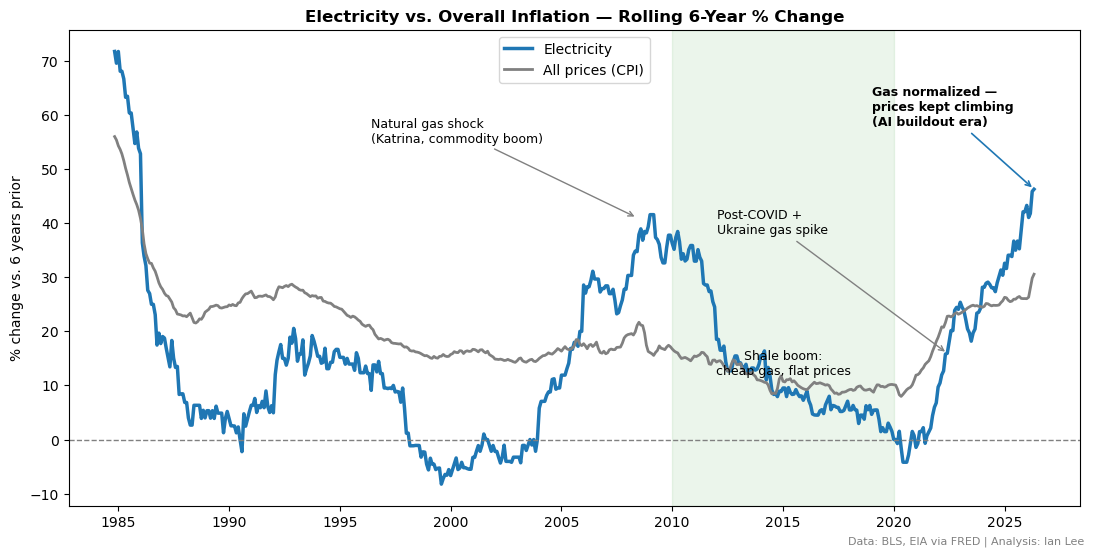

In [5]:
# The money chart
start = "1984-11-01"  # first date where the electricity rolling window exists

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(elec.loc[start:].index, elec.loc[start:, "pct_6yr"], lw=2.5, color="#1f77b4", label="Electricity")
ax.plot(cpi.loc[start:].index,  cpi.loc[start:, "pct_6yr"],  lw=2,   color="gray",    label="All prices (CPI)")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.axvspan(pd.Timestamp("2010-01-01"), pd.Timestamp("2020-01-01"), alpha=0.08, color="green")

ax.annotate("Natural gas shock\n(Katrina, commodity boom)", xy=(pd.Timestamp("2008-06-01"), 41),
            xytext=(pd.Timestamp("1996-06-01"), 55), arrowprops=dict(arrowstyle="->", color="gray", lw=1), fontsize=9)
ax.annotate("Shale boom:\ncheap gas, flat prices", xy=(pd.Timestamp("2015-01-01"), 12), fontsize=9, ha="center")
ax.annotate("Post-COVID +\nUkraine gas spike", xy=(pd.Timestamp("2022-06-01"), elec.loc["2022-06-01","pct_6yr"]),
            xytext=(pd.Timestamp("2012-01-01"), 38), arrowprops=dict(arrowstyle="->", color="gray", lw=1), fontsize=9)
ax.annotate("Gas normalized —\nprices kept climbing\n(AI buildout era)", xy=(elec.index[-1], latest),
            xytext=(pd.Timestamp("2019-01-01"), 58), arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.2),
            fontsize=9, fontweight="bold")

ax.set_title("Electricity vs. Overall Inflation — Rolling 6-Year % Change", fontweight="bold")
ax.set_ylabel("% change vs. 6 years prior")
ax.legend(loc="upper center")
fig.text(0.99, 0.0, "Data: BLS, EIA via FRED | Analysis: Ian Lee", ha="right", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("charts/electricity_money_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. The traditional driver: natural gas
Gas-fired plants are usually the marginal (price-setting) generators in US wholesale markets, so retail electricity historically tracks wholesale gas — with a lag, because utilities hedge and regulators pass fuel costs through over months.

**The ratchet test:** index both series to Jan 2020 = 100. Gas spiked ~4x in 2022 and round-tripped completely by 2024 (2022 peak: $8.81/MMBtu → 2024–26 average: ~$3.06, a ~65% decline). Electricity followed gas *up* — and never came back down. The 12-month average of gas is shown because raw spot is too volatile to read; retail rates respond to the trend, not the spikes.

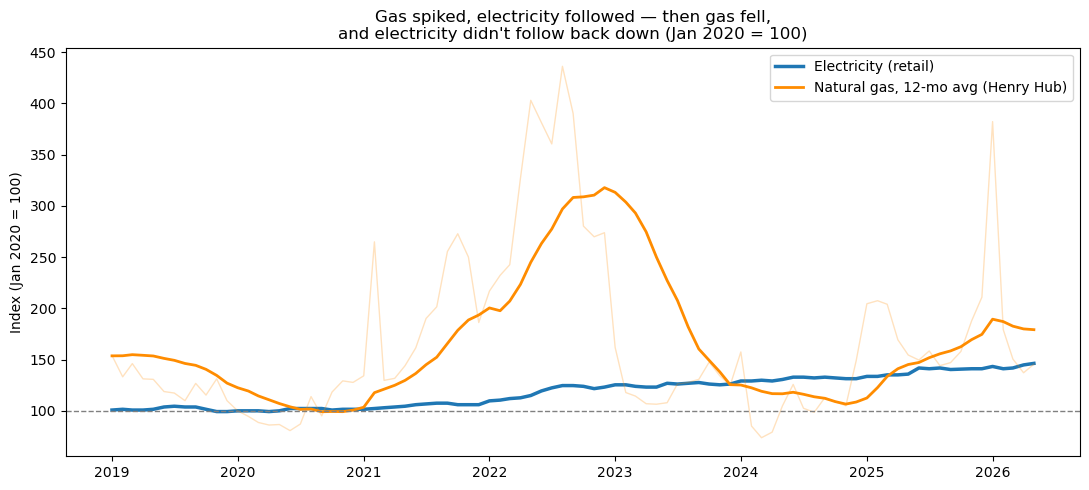

In [6]:
base = "2020-01-01"
elec_idx = elec["price"] / elec.loc[base, "price"] * 100
gas_idx  = gas["gas_price"] / gas.loc[base, "gas_price"] * 100
gas_idx_smooth = gas_idx.rolling(12).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(elec_idx.loc["2019":], lw=2.5, label="Electricity (retail)")
ax.plot(gas_idx_smooth.loc["2019":], lw=2, color="darkorange", label="Natural gas, 12-mo avg (Henry Hub)")
ax.plot(gas_idx.loc["2019":], lw=1, color="darkorange", alpha=0.25)
ax.axhline(100, color="gray", lw=1, ls="--")
ax.set_title("Gas spiked, electricity followed — then gas fell,\nand electricity didn't follow back down (Jan 2020 = 100)")
ax.set_ylabel("Index (Jan 2020 = 100)")
ax.legend()
plt.tight_layout()
plt.savefig("charts/gas_vs_electricity.png", dpi=200, bbox_inches="tight")
plt.show()

### How tightly, and with what lag, does electricity follow gas?
Correlating price *levels* of two upward-drifting series produces spurious correlation, so we work in year-over-year % changes.

In [7]:
elec_yoy = elec["price"].pct_change(12) * 100
gas_yoy  = gas["gas_price"].pct_change(12) * 100
df = pd.DataFrame({"elec": elec_yoy, "gas": gas_yoy}).dropna()

for lag in range(0, 25, 3):
    r = df["elec"].corr(df["gas"].shift(lag))
    print(f"lag {lag:>2} months: r = {r:.2f}")

lag  0 months: r = 0.15
lag  3 months: r = 0.40
lag  6 months: r = 0.53
lag  9 months: r = 0.50
lag 12 months: r = 0.37
lag 15 months: r = 0.20
lag 18 months: r = 0.06
lag 21 months: r = -0.04
lag 24 months: r = -0.09


Correlation peaks at a **6-month lag (r = 0.53, r² ≈ 0.28)** and decays to zero by ~18 months — consistent with regulated fuel-cost pass-through. Gas is the single biggest driver of electricity inflation, and it still explains less than a third of the variation.

## 5. The decomposition: what gas and inflation *can't* explain
We fit a simple OLS model — electricity YoY on 6-month-lagged gas YoY and CPI YoY — trained only on the pre-2023 era (the world where fuel was the dominant variable driver), then let it predict the full history. The residual is electricity inflation unexplained by fuel or general inflation.

**Limitations stated up front:** overlapping YoY series produce heavy autocorrelation (Durbin-Watson ≈ 0.2), so the t-statistics are overconfident — this is a descriptive decomposition, not formal inference. And the residual is "not gas, not CPI," which includes datacenter demand but also grid capex, plant retirements, and electrification.

In [8]:
best_lag = 6
df["gas_lag"] = df["gas"].shift(best_lag)
df["cpi_yoy"] = cpi["cpi"].pct_change(12) * 100
train = df.loc[:"2022-12-01"].dropna()

X = sm.add_constant(train[["gas_lag", "cpi_yoy"]])
model = sm.OLS(train["elec"], X).fit()
print(model.summary().tables[1])
print(f"\nR-squared: {model.rsquared:.3f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3339      0.342     -0.975      0.330      -1.008       0.340
gas_lag        0.0326      0.004      7.996      0.000       0.025       0.041
cpi_yoy        0.9252      0.123      7.508      0.000       0.683       1.168

R-squared: 0.425


C:\Users\idcom\AppData\Local\Temp\ipykernel_15104\2330421042.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["cpi_yoy"] = cpi["cpi"].pct_change(12) * 100


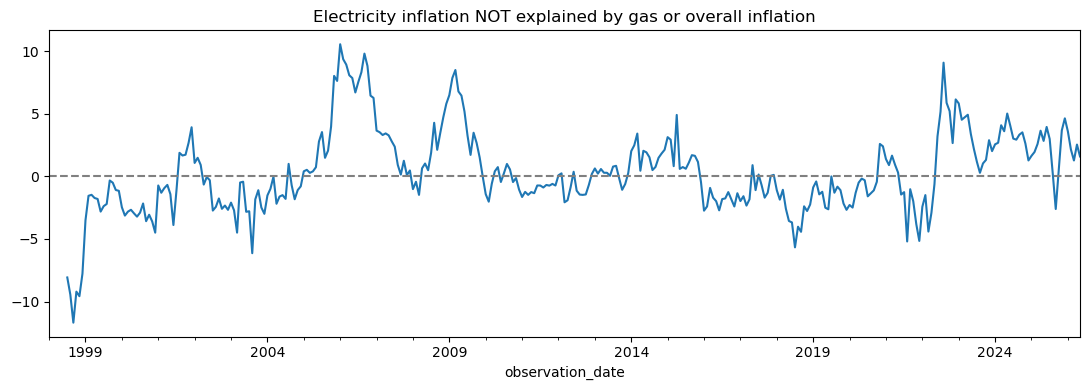

pre-2020 avg residual: -0.04
2024+   avg residual: 2.63


In [9]:
X_all = sm.add_constant(df[["gas_lag", "cpi_yoy"]])
df["resid2"] = df["elec"] - model.predict(X_all)

fig, ax = plt.subplots(figsize=(11, 4))
df["resid2"].plot(ax=ax, title="Electricity inflation NOT explained by gas or overall inflation")
ax.axhline(0, color="gray", ls="--")
plt.tight_layout()
plt.savefig("charts/residual_model.png", dpi=200, bbox_inches="tight")
plt.show()

print("pre-2020 avg residual:", round(df["resid2"].loc[:"2020"].mean(), 2))
print("2024+   avg residual:", round(df["resid2"].loc["2024":].mean(), 2))

## 6. Conclusions

1. **Electricity prices ratchet.** They follow fuel costs up with a ~6-month lag, but did not retrace when gas gave back its entire 2022 spike. The shale decade (2010–2020) shows what *used* to happen when fuel got cheap: prices went flat and the prior shock decayed. That decay is absent this time.
2. **Since 2023, roughly 3 points/year of US electricity inflation is unexplained by fuel or general inflation** — persistent positive residuals coinciding with the first sustained US electricity demand growth in two decades, driven primarily by datacenter construction, and with capacity-market repricing (PJM's capacity auction cleared roughly 9x higher year-over-year) hitting the non-fuel portion of bills.
3. **Precision matters:** similar residual episodes existed (2005–09, rate-cap expirations) and decayed within a couple of years. The honest claim is not "unprecedented" but "elevated, persistent, and attached to a driver that is growing rather than one-off."

**If extending this work:** state-level prices (PJM states vs. national), capacity-market prices as an explicit regressor, and electricity demand (EIA retail sales) to close the causal loop.

*Data: BLS and EIA via FRED. All analysis in this notebook is reproducible end-to-end — every chart regenerates from the public endpoints above.*